# Carregamento do DataSet

In [1]:
%reload_ext autoreload
%autoreload 2

from variables import filenames, features, target
from load_dataset import load
from pre_processing import apply, ReplaceInfWithNan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = load(filenames)
df = apply(df)
df.head()

Quantidade de duplicatas antes de remover:  308381


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


# Preprocessamento

In [13]:
df = df[df['Label'].isin(['BENIGN','DoS slowloris', 'DoS Slowhttptest', 'DoS Hulk', 'DoS GoldenEye'])]
df['Label'].value_counts()

Label
BENIGN              2096484
DoS Hulk             172849
DoS GoldenEye         10286
DoS slowloris          5385
DoS Slowhttptest       5228
Name: count, dtype: int64

In [14]:
# Remove valores nulos e infinitos da base
df.replace([np.inf, -np.inf], np.nan, inplace=True)

linhas_antes = len(df)
valores_nulos_antes = int(df.isna().sum().sum())

df.dropna(inplace=True)

print(f"Linhas antes: {linhas_antes}")
print(f"Valores nulos/inf convertidos para NaN: {valores_nulos_antes}")
print(f"Linhas após limpeza: {len(df)}")
print(f"Total de NaN restantes: {int(df.isna().sum().sum())}")

Linhas antes: 2290232
Valores nulos/inf convertidos para NaN: 2860
Linhas após limpeza: 2288802
Total de NaN restantes: 0


In [15]:
df.drop(columns=["Destination Port"], inplace=True)

In [16]:
cols = df.columns.drop("Label", errors="ignore")

colunas_quase_constantes = []

for col in cols:
    # conta a proporção do valor mais frequente
    proporcao_maior_valor = df[col].value_counts(normalize=True, dropna=False).iloc[0]
    
    if proporcao_maior_valor > 0.99:
        colunas_quase_constantes.append(col)

print("\nColunas com mais de 99% de um único valor:")
print(colunas_quase_constantes)

# remove do dataframe
df = df.drop(columns=colunas_quase_constantes, errors="ignore")

print(f"\nTotal de colunas removidas: {len(colunas_quase_constantes)}")


Colunas com mais de 99% de um único valor:
['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'RST Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']

Total de colunas removidas: 12


In [17]:
#Remover a coluna "Fwd Header Length.1" por ser idêntica à "Fwd Header Length"
if "Fwd Header Length.1" in df.columns:
    df.drop(columns=["Fwd Header Length.1"], inplace=True)
    print("Coluna 'Fwd Header Length.1' removida por ser idêntica a 'Fwd Header Length'.")

Coluna 'Fwd Header Length.1' removida por ser idêntica a 'Fwd Header Length'.


# Analise do Dataset

In [10]:
df.head()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,3,2,0,12,0,6,6,6.0,0.0,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,109,1,1,6,6,6,6,6.0,0.0,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,52,1,1,6,6,6,6,6.0,0.0,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,34,1,1,6,6,6,6,6.0,0.0,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,3,2,0,12,0,6,6,6.0,0.0,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [8]:
col1, col2 = "Fwd Header Length", "Fwd Header Length.1"

if col1 not in df.columns or col2 not in df.columns:
    print(f"Coluna ausente. Disponíveis? {col1 in df.columns=}, {col2 in df.columns=}")
else:
    iguais = df[col1].equals(df[col2])  # compara considerando NaN na mesma posição como igual
    print(f"As colunas '{col1}' e '{col2}' são totalmente iguais? {iguais}")

    mask_diff = ~(df[col1].eq(df[col2]) | (df[col1].isna() & df[col2].isna()))
    qtd_diff = int(mask_diff.sum())
    total = len(df)

    print(f"Total de linhas: {total}")
    print(f"Linhas diferentes: {qtd_diff} ({(qtd_diff/total)*100:.6f}%)")

    if qtd_diff > 0:
        print("\nExemplos de diferenças:")
        display(df.loc[mask_diff, [col1, col2]].head(10))

As colunas 'Fwd Header Length' e 'Fwd Header Length.1' são totalmente iguais? True
Total de linhas: 2288802
Linhas diferentes: 0 (0.000000%)


# Treinamento Modelo


In [18]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df["Class"] = label_encoder.fit_transform(df["Label"].astype(str))

mapa_classes = pd.DataFrame({
    "Label": label_encoder.classes_,
    "Class": range(len(label_encoder.classes_))
})

display(mapa_classes)

,Label,Class
0,BENIGN,0
1,DoS GoldenEye,1
2,DoS Hulk,2
3,DoS Slowhttptest,3
4,DoS slowloris,4


In [19]:
df.drop(columns=["Label"], inplace=True)

## Separação Treino/Teste


In [20]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df, test_size=0.20, random_state=42, stratify=df['Class'])

## Balanceamento

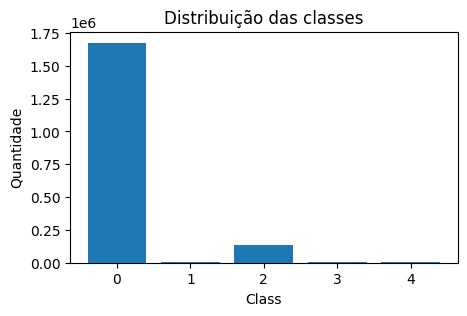

In [28]:
def plot_class_distribution(df, class_col="Class"):
    counts = df[class_col].value_counts().sort_index()
    plt.figure(figsize=(5,3))
    plt.bar(counts.index.astype(str), counts.values)
    plt.title("Distribuição das classes")
    plt.xlabel("Class")
    plt.ylabel("Quantidade")
    plt.show()
plot_class_distribution(df_train)

In [29]:
df_train['Class'].value_counts()

Class
0    1676045
2     138277
1       8229
4       4308
3       4182
Name: count, dtype: int64

In [22]:
from imblearn.under_sampling import RandomUnderSampler

def aplicar_undersampling_por_proporcao(
    df,
    target_col="Class",
    proporcao=10,
    classe_referencia=None,
    random_state=42
):
    """
    Aplica undersampling no DataFrame inteiro e retorna apenas o DataFrame balanceado.

    proporcao=10 -> classes majoritárias terão no máximo 10x a quantidade da menor classe
    proporcao=20 -> classes majoritárias terão no máximo 20x a quantidade da menor classe
    """

    class_counts = df[target_col].value_counts()

    if classe_referencia is None:
        menor_qtd = class_counts.min()
    else:
        menor_qtd = class_counts[classe_referencia]

    limite = menor_qtd * proporcao

    sampling_strategy = {
        classe: min(qtd, limite)
        for classe, qtd in class_counts.items()
    }

    rus = RandomUnderSampler(
        sampling_strategy=sampling_strategy,
        random_state=random_state
    )

    df_bal, _ = rus.fit_resample(
        df,
        df[target_col]
    )

    return df_bal

In [65]:
df_train_bal = aplicar_undersampling_por_proporcao(
    df_train,
    target_col="Class",
    proporcao=10
)

df_train_bal["Class"].value_counts()


Class
0    41820
2    41820
1     8229
4     4308
3     4182
Name: count, dtype: int64

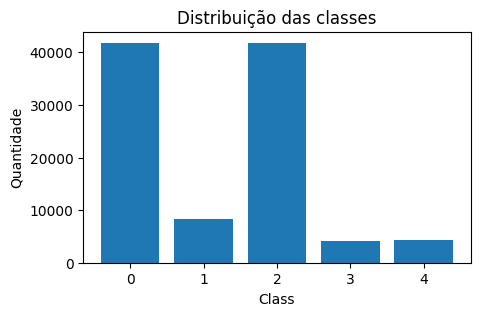

In [66]:
plot_class_distribution(df_train_bal)

# Treinamento

In [67]:
X_train = df_train.drop(columns=["Class"])
X_train_bal = df_train_bal.drop(columns=["Class"])

y_train = df_train["Class"]
Y_train_bal = df_train_bal["Class"]

X_test = df_test.drop(columns=["Class"])
y_test = df_test["Class"]

In [81]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from pre_processing import ReplaceInfWithNan

model = Pipeline(steps=[
    ("replace_inf", ReplaceInfWithNan()),
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", RandomForestClassifier(random_state=42, n_estimators=100, warm_start=True))
])

In [61]:
from sklearn.ensemble import RandomForestClassifier
import time

randomForest = RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1, class_weight='balanced')
start = time.time()
randomForest.fit(X_train, y_train)
end = time.time()
print(f"Treinamento concluído em {end - start:.2f} segundos")

Treinamento concluído em 112.58 segundos


In [68]:
from sklearn.ensemble import RandomForestClassifier
import time

randomForest_bal = RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1)
start = time.time()
randomForest_bal.fit(X_train_bal, Y_train_bal)
end = time.time()
print(f"Treinamento concluído em {end - start:.2f} segundos")

Treinamento concluído em 2.44 segundos


## Salvamento do Modelo e Scaler

In [63]:
import joblib
import os 

#Cria a pasta modelo caso não exista
os.makedirs("modelo", exist_ok=True)

# Salvar o modelo treinado
joblib.dump(randomForest, "./modelo/random_forest.joblib")
joblib.dump(randomForest_bal, "./modelo/random_forest_balanced.joblib")

# Salvar o LabelEncoder
joblib.dump(label_encoder, "modelo/label_encoder.joblib")

# Salvar o scaler
#joblib.dump(scaler, "modelo/minmax_scaler.joblib")

['modelo/label_encoder.joblib']

## Avaliação do Modelo

In [69]:
y_predict = randomForest_bal.predict(X_test)

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

def show_classification_metrics(y_true, y_pred):
    print("Acurácia:", accuracy_score(y_true, y_pred))
    print("Precisão:", precision_score(y_true, y_pred, average='weighted'))
    print("Recall:", recall_score(y_true, y_pred, average='weighted'))
    print("F1 Score:", f1_score(y_true, y_pred, average='weighted'))
    print("\nRelatório de Classificação:")
    print(classification_report(y_true, y_pred))

    # Matriz de confusão gráfica
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predito')
    plt.ylabel('Real')
    plt.title('Matriz de Confusão')
    plt.show()

def plot_roc_auc(y_true, y_pred_proba):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    auc = roc_auc_score(y_true, y_pred_proba)
    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('FPR (False Positive Rate)')
    plt.ylabel('TPR (True Positive Rate)')
    plt.title('Curva ROC')
    plt.legend(loc='lower right')
    plt.show()
    print(f'AUC: {auc:.4f}')

Acurácia: 0.998145320374606
Precisão: 0.9981966553930901
Recall: 0.998145320374606
F1 Score: 0.9981586756336205

Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    419012
           1       0.97      1.00      0.98      2057
           2       0.98      1.00      0.99     34569
           3       0.89      1.00      0.94      1046
           4       0.96      0.99      0.98      1077

    accuracy                           1.00    457761
   macro avg       0.96      1.00      0.98    457761
weighted avg       1.00      1.00      1.00    457761



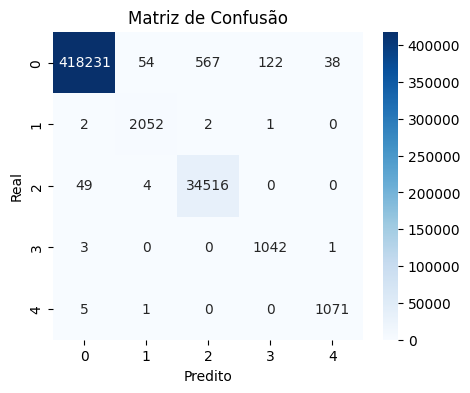

In [70]:
show_classification_metrics(y_test, y_predict)

In [40]:
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)


def comparar_modelos_multiclasse(
    modelo_1,
    modelo_2,
    X_test,
    y_test,
    nome_1="Modelo 1",
    nome_2="Modelo 2"
):
    """
    Compara dois modelos de classificação multiclasse no conjunto de teste.

    Retorna:
    - tabela_agregada: métricas gerais dos modelos
    - tabela_por_classe: métricas por classe para cada modelo
    """

    modelos = {
        nome_1: modelo_1,
        nome_2: modelo_2
    }

    resultados_agregados = []
    resultados_por_classe = []

    for nome, modelo in modelos.items():
        y_pred = modelo.predict(X_test)

        # Métricas agregadas
        resultados_agregados.append({
            "Modelo": nome,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision Macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
            "Recall Macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
            "F1 Macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
            "Precision Weighted": precision_score(y_test, y_pred, average="weighted", zero_division=0),
            "Recall Weighted": recall_score(y_test, y_pred, average="weighted", zero_division=0),
            "F1 Weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        })

        # Métricas por classe
        report = classification_report(
            y_test,
            y_pred,
            output_dict=True,
            zero_division=0
        )

        for classe, metricas in report.items():
            if classe in ["accuracy", "macro avg", "weighted avg"]:
                continue

            resultados_por_classe.append({
                "Modelo": nome,
                "Classe": classe,
                "Precision": metricas["precision"],
                "Recall": metricas["recall"],
                "F1-score": metricas["f1-score"],
                "Support": metricas["support"]
            })

    tabela_agregada = pd.DataFrame(resultados_agregados).set_index("Modelo")

    tabela_por_classe = pd.DataFrame(resultados_por_classe)
    tabela_por_classe = tabela_por_classe.set_index(["Modelo", "Classe"])

    return tabela_agregada, tabela_por_classe

In [64]:
tabela_agregada, tabela_por_classe = comparar_modelos_multiclasse(
    randomForest,
    randomForest_bal,
    X_test,
    y_test,
    nome_1="Random Forest",
    nome_2="Random Forest Balanceado"
)

display(tabela_agregada)
display(tabela_por_classe)

,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted
Modelo,,,,,,,
Random Forest,0.999386,0.987537,0.995686,0.991492,0.999392,0.999386,0.999388
Random Forest Balanceado,0.998670,0.971710,0.997020,0.983969,0.998700,0.998670,0.998677


Precision    Recall  F1-score   Support
Modelo                   Classe                                         
Random Forest            0        0.999668  0.999687  0.999678  419012.0
                         1        0.996590  0.994652  0.995620    2057.0
                         2        0.997885  0.996355  0.997119   34569.0
                         3        0.945405  0.993308  0.968765    1046.0
                         4        0.998136  0.994429  0.996279    1077.0
Random Forest Balanceado 0        0.999919  0.998649  0.999284  419012.0
                         1        0.978988  0.996597  0.987714    2057.0
                         2        0.988327  0.999248  0.993757   34569.0
                         3        0.913234  0.996176  0.952904    1046.0
                         4        0.978082  0.994429  0.986188    1077.0